#### The separation distirbutions of the binary white dwarf (WDWD) and binary neutron star (NSNS) systems that merge within a Hubble Time and their progenitors

Let's first look at the separation distirbutions of the compact objects themselves

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

Similarly to the formation efficiencies and delay times our systems of interest are those that merge in a Hubble Time and are 
1) two neutron stars (NSNS)
2) a carbon oyxygen white dwarf and any white dwarf (COWD+WD)

We will use the DCOmask filter to help us select for these systems, and then booleans to make further selections.
We will use the NSNS optimized run to analyze the delay time distribution for the NSNS systems, and the WDWD optimized run to look at the delay time distribution for the COWD+WD systems.

In [2]:
# let's read in our files for the fiducial case

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

DATA_SPS = Data_NSNS['BSE_System_Parameters']

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# gathering information to mask the data even more
# merges in a Hubble Time
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers = Merges_Hubble_Time == True

# gathering just the DCO objects that merge within a Hubble Time
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_merged = stellar_types_all_1[DCO_mask_NSNS*condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_merged = stellar_types_all_2[DCO_mask_NSNS*condition_mergers]

# bool for just the NSNS systems
NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

# gathering the mixture weight info
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixtrue_weights_merged = mixture_weights_all[DCO_mask_NSNS*condition_mergers]
mixture_weights_merged_NSNS = mixtrue_weights_merged[NSNS_systems_bool]

# gathering the separations info
seps_DCO = DCOs_NSNS['SemiMajorAxis@DCO'][()]
seps_merged = seps_DCO[DCO_mask_NSNS*condition_mergers]
seps_merged_NSNS = seps_merged[NSNS_systems_bool]

#### Let's do the same for the WDWD systems

In [4]:
## WDWD optimized run
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [5]:
# merging conditions
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers_WDopt = Merges_Hubble_Time_WDopt == True

stellar_types_all_1_WD_opt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_merged_WDopt = stellar_types_all_1_WD_opt[DCO_mask_WDWD*condition_mergers_WDopt]

stellar_types_all_2_WDopt = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_merged_WDopt = stellar_types_all_2_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# BWD bool with at least one COWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixtrue_weights_merged_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]
mixture_weights_merged_COWD_WDopt = mixtrue_weights_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

# gathering the separations info
seps_DCO_WDopt = DCOs_WDWD['SemiMajorAxis@DCO'][()]
seps_merged_WDopt = seps_DCO_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]
seps_merged_WDWD = seps_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

### Plotting!

In [6]:
# let's check the units of the separations before plotting

print(DCOs_WDWD['SemiMajorAxis@DCO'].attrs['units']) 

b'AU'


Text(0.5, 0.98, 'Separation Distributions')

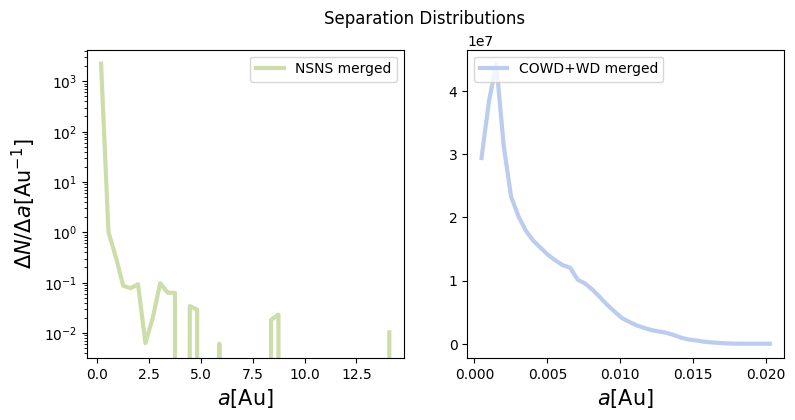

In [9]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(seps_merged_NSNS, weights=mixture_weights_merged_NSNS, bins=40, density=False)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
bin_widths = np.diff(bin_edges)

axs[0].plot(bin_centers, hist/bin_widths, color=cset.pale_green, lw=3, label='NSNS merged')
axs[0].set_yscale('log')
# axs[0].set_xlim(0, 0.020)


# axs[0].set_ylabel(r'$\mathrm{dN/d}\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_ylabel(r'$\mathrm{\Delta}N/\mathrm{\Delta}a [\mathrm{Au}^{-1}]$', fontsize=15)
axs[0].set_xlabel(r'$a[\mathrm{Au}]$', fontsize=15)

axs[0].legend()

# COWD+WD
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(seps_merged_WDWD, weights=mixture_weights_merged_COWD_WDopt, bins=40, density=False)

bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2
bin_widths_WDWD = np.diff(bin_edges_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_WDopt, hist_WDWD_WDopt/bin_widths_WDWD, color=cset.pale_blue, lw=3, label='COWD+WD merged')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$a[\mathrm{Au}]$', fontsize=15)

axs[1].legend(loc='upper left')

fig.suptitle('Separation Distributions')

### Separations of progenitors

Let's now get the distirbution of the progenitors

In [10]:
# Let's first get the SEED of these systems that eventually become NSNS and WDWD that maerge within a Hubble Time

### NSNS systems
seeds = DCOs_NSNS['SEED'][()]
seeds_dco = seeds[DCO_mask_NSNS*condition_mergers]
seeds_NSNS = seeds_dco[NSNS_systems_bool]

In [11]:
seed_criteria = np.where(np.isin(DATA_SPS['SEED'][()], seeds_NSNS))[0] # np.isin good since we want to compare tow unequal length arrays
seps_zams = DATA_SPS['SemiMajorAxis@ZAMS'][()]
seps_progenitors = seps_zams[seed_criteria]

In [12]:
### WDWD systems
seeds_WDopt = DCOs_WDWD['SEED'][()]
seeds_dco_WDopt = seeds_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]
seeds_WDWD = seeds_dco_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

seed_criteria_WDopt = np.where(np.isin(DATA_SPS_WDWD['SEED'][()], seeds_WDWD))[0] # np.isin good since we want to compare tow unequal length arrays
seps_zams_WDopt = DATA_SPS_WDWD['SemiMajorAxis@ZAMS'][()]
seps_progenitors_WDopt = seps_zams_WDopt[seed_criteria_WDopt]

### Plotting progenitor separations

Text(0.5, 0.98, 'Progenitors Separation Distributions')

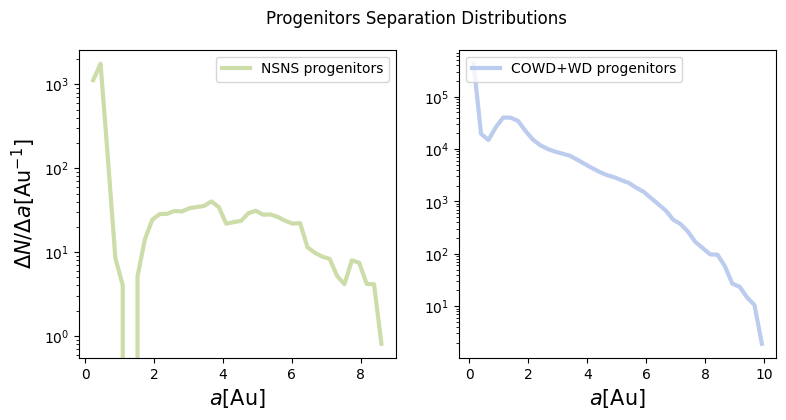

In [13]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(seps_progenitors, weights=mixture_weights_merged_NSNS, bins=40, density=False)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
bin_widths = np.diff(bin_edges)

axs[0].plot(bin_centers, hist/bin_widths, color=cset.pale_green, lw=3, label='NSNS progenitors')
axs[0].set_yscale('log')
# axs[0].set_xlim(0, 0.020)


# axs[0].set_ylabel(r'$\mathrm{dN/d}\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_ylabel(r'$\mathrm{\Delta}N/\mathrm{\Delta}a [\mathrm{Au}^{-1}]$', fontsize=15)
axs[0].set_xlabel(r'$a[\mathrm{Au}]$', fontsize=15)

axs[0].legend()

# COWD+WD
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(seps_progenitors_WDopt, weights=mixture_weights_merged_COWD_WDopt, bins=40, density=False)

bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2
bin_widths_WDWD = np.diff(bin_edges_WDWD_WDopt)
    
axs[1].plot(bin_centers_WDWD_WDopt, hist_WDWD_WDopt/bin_widths_WDWD, color=cset.pale_blue, lw=3, label='COWD+WD progenitors')
axs[1].set_yscale('log')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$a[\mathrm{Au}]$', fontsize=15)

axs[1].legend(loc='upper left')

fig.suptitle('Progenitors Separation Distributions')

In [14]:
# closing data file
Data_NSNS.close()
Data_WDWD.close()